# Mocking a Linear Transformation approach

In [1]:
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import numpy as np
import transformers
from transformers import BertModel, BertTokenizer
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

/Users/giacomomunda/Documents/MSc Multilingual Technologies/Masters_Thesis/code/kg_linear_transformation/linear-venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train = pd.read_csv('data/train.csv')
val = pd.read_csv('data/val.csv')
train

,Entity1,Entity2,Similarity
0,Germany,Angela Merkel,0.872515
1,Germany,Berlin,0.842976
2,Computer,Artificial Intelligence,0.918676
3,Olympic Games,Athens,0.723022
4,Bed,Mattress,0.668821
...,...,...,...
81,Library,Museum,0.761234
82,Laptop,Desktop,0.698753
83,Beach,Island,0.724895
84,Horse,Cow,0.721436


## 1st approach

The linear transformation here is one embedding of weights with dimensionality of 768 (same as the input embeddings). The weights in the linear tranformation are then applied to the new embeddings when performing inference to predict the similarity score.

I do not know if this approach is valid. I think it is a simple *Linear Regression*

In [3]:
# Mock data
num_samples = 1000
embedding_dimension = 768  # Mock BERT embeddings dimension

# Mock BERT embeddings for two entities (100 samples)
E1 = torch.randn(num_samples, embedding_dimension)
E2 = torch.randn(num_samples, embedding_dimension)

print(E1.shape)

# Mock actual similarity scores (100 samples)
actual_similarity_scores = torch.rand(num_samples, 1)

# Linear model
linear_model = nn.Linear(embedding_dimension, 1)
print(linear_model.parameters())

# Loss function (Mean Squared Error)
loss_function = nn.MSELoss()

# Optimizer (Stochastic Gradient Descent)
optimizer = optim.SGD(linear_model.parameters(), lr=0.01)

# Training loop
num_epochs = 1000

for epoch in range(num_epochs):
    optimizer.zero_grad()
    # Predict similarity scores
    predicted_scores = linear_model(E1 - E2)
    # Compute the loss
    loss = loss_function(predicted_scores, actual_similarity_scores)
    # Backpropagation
    loss.backward()
    # Update weights
    optimizer.step()

# Extract the learned weight for your similarity prediction
learned_weights = linear_model.weight.detach().numpy()
print("Learned Weights:", learned_weights.shape)

torch.Size([1000, 768])
<generator object Module.parameters at 0x154fedcb0>
Learned Weights: (1, 768)


In [4]:
# Assuming E_new and E_existing are contextual embeddings for a pair of entities
E_new = torch.randn(1, embedding_dimension)
E_existing = torch.randn(1, embedding_dimension)

# Use the trained linear model to predict the similarity score
predicted_score = linear_model(E_new - E_existing)

# Convert the result to a similarity score (if necessary)
similarity_score = predicted_score.item()

print("Predicted Similarity Score:", similarity_score)

Predicted Similarity Score: 0.770807683467865


In [5]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 2nd approach

1. **Original Embeddings Matrix (M)**: You start with an original embeddings matrix where each row represents an entity and each column represents a dimension in the embedding space. So, you have an *m* x *n* matrix, where *m* is the number of entities, and *n* is the dimensionality of the embeddings (e.g., 768 for BERT).

2. **Linear Transformation (B)**: The linear transformation matrix B also has dimensions *m* x *n*. You train this matrix to map the original embeddings to a transformed space. The objective is to find a transformation that minimizes the difference between the predicted similarity scores and the true similarity scores. You're essentially learning a set of weights (θ) for each dimension of your embeddings to make the predictions as accurate as possible.

3. **Predicted Similarity Scores**: After applying the linear transformation, you calculate predicted similarity scores for pairs of entities based on their transformed embeddings. The linear model allows to compute the predicted similarity scores.

4. **Loss Minimization**: You use a loss function to measure the difference between the predicted similarity scores and the true similarity scores. The training process adjusts the values in the linear transformation matrix B to minimize this loss.

The overall approach of using a linear transformation to capture relationships and predict similarity scores between entities based on embeddings is sound. The linear transformation aims to learn a set of weights for each dimension of the embeddings that result in accurate predictions of similarity or relatedness. This process allows you to enhance the original embeddings to better reflect the relationships between entities as represented in your knowledge graph or dataset.

**KEEP ATTENTION TO:**

Increasing the number of epochs leads to exploding and vanishing gradients, where they either become too big or too small, leading to incorrect similarity scores or even to -inf values in the transformation matrix

In [8]:
num_samples = 10000  # I have 100 entities in the dataset in this case
embedding_dimension = 768

# Mock BERT embeddings for entities (100 samples)
original_embeddings = torch.randn(num_samples, embedding_dimension)

# Mock actual similarity scores (100 samples)
actual_similarity_scores = torch.rand(num_samples, 1)

# Linear transformation matrix
# takes as input an embedding with dimension 768 and outputs an embedding with dimension 768
linear_transformation = nn.Linear(embedding_dimension, embedding_dimension) 

# Loss function (Mean Squared Error)
loss_function = nn.MSELoss()

# Optimizer (Stochastic Gradient Descent)
optimizer = optim.SGD(linear_transformation.parameters(), lr=0.01, weight_decay=0.005)

# Training loop
num_epochs = 1

for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Apply linear transformation to the original embeddings
    transformed_embeddings = linear_transformation(original_embeddings)

    # Predict similarity scores
    predicted_scores = torch.sum(transformed_embeddings, dim=1, keepdim=True)  # A simple aggregation

    # Compute the loss
    loss = loss_function(predicted_scores, actual_similarity_scores)

    # Backpropagation
    loss.backward()

    # Update the linear transformation matrix
    optimizer.step()

# Extract the learned linear transformation matrix
learned_transformation = linear_transformation.weight.detach().numpy()

print("Learned Linear Transformation Matrix:\n", learned_transformation)
print(learned_transformation.shape)

Learned Linear Transformation Matrix:
 [[ 0.0245974  -0.04059676  0.00734807 ... -0.03219556 -0.01557682
  -0.02231996]
 [-0.02427743  0.00688579 -0.03319169 ... -0.02029143 -0.02597748
   0.00079784]
 [-0.00730389 -0.04047353 -0.01525484 ... -0.00767516 -0.01371442
   0.01006992]
 ...
 [ 0.00415139 -0.01383741 -0.02033857 ...  0.00671067  0.01726963
  -0.01705671]
 [-0.01719469 -0.01830455 -0.02630087 ... -0.02319024 -0.03199568
   0.02274515]
 [-0.01553327  0.01843481  0.02163902 ...  0.02347566  0.02474752
   0.03017666]]
(768, 768)


In [46]:
count_parameters(linear_transformation)

590592

In [3]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
# Assuming E1 and E2 are contextual embeddings for two entities
E1 = torch.randn(1, embedding_dimension)
E2 = torch.randn(1, embedding_dimension)

# Apply the trained linear transformation
transformed_E1 = np.dot(E1, learned_transformation.T)
transformed_E2 = np.dot(E2, learned_transformation.T)

# Calculate cosine similarity between the transformed embeddings
similarity_score = cosine_similarity(transformed_E1, transformed_E2)

print("Predicted Similarity Score:", similarity_score[0][0])

Predicted Similarity Score: 0.19447282


## Using actual data

In [37]:
train_data = pd.read_csv('data/train.csv')
val_data = pd.read_csv('data/val.csv')

In [2]:
class CreateBERTEmbeddings:
    '''
    Class to create BERT embeddings for the entities
    in the dataset.
    '''
    def __init__(self, model_name: str) -> None:
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.model = BertModel.from_pretrained(model_name)

    def __call__(self, entity_text: str) -> torch.Tensor:
        inputs = self.tokenizer(entity_text, return_tensors='pt', padding=True, truncation=True)
        outputs = self.model(**inputs)
        embeddings = outputs.last_hidden_state.mean(dim=1)

        return embeddings


class DataPreparation:
    def __init__(self, model_name: str, contextual_embeddings: torch.Tensor) -> None:
        self.model_name = model_name
        self.contextual_embeddings = contextual_embeddings

    def get_normalized_embeddings(self, entity_text: str) -> torch.Tensor:
        '''
        Method to L2 normalize embeddings for the given entity text
        '''
        embeddings = self.contextual_embeddings(entity_text)
        embeddings = embeddings.detach().clone().requires_grad_(True)
        normalized_embeddings = embeddings / torch.linalg.vector_norm(embeddings)

        return normalized_embeddings

    def prepare_data(self, data: str) -> tuple[torch.Tensor, torch.Tensor]:
        '''
        Returns two lists of normalized embeddings and 
        similarity scores for the given dataset
        '''
        normalized_embeddings = []
        similarity_scores = []

        for _, row in data.iterrows():
            entity1 = row['Entity1']
            entity2 = row['Entity2']
            similarity = row['Similarity']

            embeddings1_normalized = self.get_normalized_embeddings(entity1)
            embeddings2_normalized = self.get_normalized_embeddings(entity2)

            normalized_embeddings.append(embeddings1_normalized)
            normalized_embeddings.append(embeddings2_normalized)
            similarity_scores.append(similarity)

        normalized_embeddings = torch.cat(normalized_embeddings)
        similarity_scores = torch.tensor(similarity_scores).view(-1, 1)

        return normalized_embeddings, similarity_scores

In [15]:
class LinearTransformation(nn.Module):
    def __init__(self, input_dim: int, output_dim: int) -> None:
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


class OrthogonalLayer(nn.Module):
    def __init__(self, input_dim):
        super(OrthogonalLayer, self).__init__()
        self.weights = nn.Parameter(torch.Tensor(input_dim, input_dim))
        nn.init.orthogonal_(self.weights)

    def forward(self, x):
        # perform the vector-matrix multiplication
        # it takes an input tensor and applies the orthogonal transformation, producing a tensor as output
        return F.linear(x, self.weights)

In [14]:
def compute_pearson_correlation(predicted: torch.Tensor, actual: torch.Tensor) -> float:
    predicted = predicted.squeeze().cpu().detach().numpy()
    actual = actual.squeeze().cpu().detach().numpy()
    corr, _ = pearsonr(predicted, actual)

    return corr

def compute_spearman_correlation(predicted: torch.Tensor, actual: torch.Tensor) -> float:
    predicted = predicted.squeeze().cpu().detach().numpy()
    actual = actual.squeeze().cpu().detach().numpy()
    corr, _ = spearmanr(predicted, actual)

    return corr

In [4]:
train_data = pd.read_csv('data/train.csv')
val_data = pd.read_csv('data/val.csv')
MODEL_NAME = 'bert-base-uncased'

bert_embeddings = CreateBERTEmbeddings(MODEL_NAME)
data_prep = DataPreparation(MODEL_NAME, bert_embeddings)
normalized_embeddings_train, similarity_scores_train = data_prep.prepare_data(train_data)
normalized_embeddings_val, similarity_scores_val = data_prep.prepare_data(val_data)

In [24]:
EMBEDDING_DIM = normalized_embeddings_train.shape[1]

linear_transformation = LinearTransformation(EMBEDDING_DIM, EMBEDDING_DIM)
#linear_transformation = nn.Linear(EMBEDDING_DIM, EMBEDDING_DIM)
#linear_transformation = OrthogonalLayer(EMBEDDING_DIM)

loss_function = nn.MSELoss()
optimizer = optim.AdamW(linear_transformation.parameters(), lr=0.05, weight_decay=0.005)

NUM_EPOCHS = 40

for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()
    # Apply linear transformation to the original embeddings
    transformed_embeddings = linear_transformation(normalized_embeddings_train)

    # Predict similarity scores
    # aggregating the predicted similarity scores for each entity pair
    # necessary because we initially have two predicted scores for each entity pair, and we want to combine them
    # into a single score that represents the overall similarity between the pairs
    predicted_scores = torch.mean(transformed_embeddings.view(
        len(similarity_scores_train), 2, -1), 
        dim=1,
        keepdim=True
    )
    predicted_scores = torch.mean(predicted_scores, dim=-1, keepdim=True)
    # Reshape predicted_scores to match the shape of similarity_scores
    predicted_scores = predicted_scores.view_as(similarity_scores_train)

    loss = loss_function(predicted_scores, similarity_scores_train)
    loss.backward(retain_graph=True)
    optimizer.step()

    # Calculate the Pearson correlation coefficient for evaluation
    corr = compute_pearson_correlation(predicted_scores, similarity_scores_train)

    # Evaluation on the validation set
    with torch.no_grad():
        transformed_embeddings_val = linear_transformation(normalized_embeddings_val)
        predicted_scores_val = torch.mean(transformed_embeddings_val.view(
            len(similarity_scores_val), 2, -1), 
            dim=1,
            keepdim=True
        )
        predicted_scores_val = torch.mean(predicted_scores_val, dim=-1, keepdim=True)
        predicted_scores_val = predicted_scores_val.view_as(similarity_scores_val)

        loss_val = loss_function(predicted_scores_val, similarity_scores_val)
        corr_val = compute_pearson_correlation(predicted_scores_val, similarity_scores_val)

    #if (epoch + 1) % 10 == 0:
    print(f'Epoch [{epoch + 1}/{NUM_EPOCHS}], Loss: {loss.item()}, Pearson Correlation (Train): {corr}')
    print(f'Validation - Loss: {loss_val.item()}, Pearson Correlation (Validation): {corr_val} \n')

#torch.save(linear_transformation.state_dict(), 'models/linear_transformation.pth')

#learned_transformation = linear_transformation.weight.detach().numpy()
learned_transformation = list(linear_transformation.parameters())[0].detach().numpy()
print(learned_transformation.shape)

Epoch [1/40], Loss: 0.4551584720611572, Pearson Correlation (Train): -0.23176573566378111
Validation - Loss: 0.24704650044441223, Pearson Correlation (Validation): -0.15177771108159832 

Epoch [2/40], Loss: 0.05084369331598282, Pearson Correlation (Train): -0.08201757122620648
Validation - Loss: 0.7281684279441833, Pearson Correlation (Validation): -0.14292161121655297 

Epoch [3/40], Loss: 0.3297836184501648, Pearson Correlation (Train): -0.051304939586005065
Validation - Loss: 0.5537979602813721, Pearson Correlation (Validation): -0.12070845337454375 

Epoch [4/40], Loss: 0.21492116153240204, Pearson Correlation (Train): -0.004874188194508244
Validation - Loss: 0.21319420635700226, Pearson Correlation (Validation): -0.07285729809647029 

Epoch [5/40], Loss: 0.0362587533891201, Pearson Correlation (Train): 0.09122829818583092
Validation - Loss: 0.05067479610443115, Pearson Correlation (Validation): 0.03335302884916996 

Epoch [6/40], Loss: 0.04684514179825783, Pearson Correlation (Tra

## Evaluation on trained model

In [ ]:
test_data = pd.read_csv('./../../data/dataset/wikidata5m_42k_test.csv')
MODEL_NAME = 'bert-base-uncased'

EMBEDDINGS_PYTORCH_TEST = './../../data/embeddings/wikidata5m_42k_test_embeddings_bert_cls.pt'
utils = UtilityFunctions()

saved_test_embeddings, similarity_scores_test = utils.load_embeddings_and_scores_from_torch(EMBEDDINGS_PYTORCH_TEST)
normalized_embeddings_test = saved_test_embeddings

EMBEDDING_DIM = normalized_embeddings_test.shape[1]

trained_model = './../../trained_models/42k_orthogonal_bert_cls.pth'
checkpoint = torch.load(trained_model)

if 'orthogonal' in trained_model:
    loaded_transformation = checkpoint['model_class'](EMBEDDING_DIM)
else:
    # load the weights into the model
    loaded_transformation = checkpoint['model_class'](EMBEDDING_DIM, EMBEDDING_DIM)

# loading the state dictionary
loaded_transformation.load_state_dict(checkpoint['state_dict'])
loaded_transformation.eval()

transformed_embeddings = loaded_transformation(normalized_embeddings_test)
predicted_similarity_scores = F.cosine_similarity(
    transformed_embeddings[::2],
    transformed_embeddings[1::2],
    dim=1
).view(-1, 1)

person_correlation = utils.compute_pearson_correlation(predicted_similarity_scores, similarity_scores_test)
spearman_correlation = utils.compute_spearman_correlation(predicted_similarity_scores, similarity_scores_test)
mean_squared_error = utils.compute_mean_squared_error(predicted_similarity_scores, similarity_scores_test)
root_mean_squared_error = utils.compute_root_mean_squared_error(predicted_similarity_scores, similarity_scores_test)

print(f"Person correlation: {person_correlation}")
print(f"Spearman correlation: {spearman_correlation}")
print(f"Mean squared error: {mean_squared_error}")
print(f"Root mean squared error: {root_mean_squared_error}")

## Training Loop

In [ ]:
train_data = pd.read_csv('./../../data/dataset/wikidata5m_42k_train.csv')
val_data = pd.read_csv('./../../data/dataset/wikidata5m_42k_valid.csv')

MODEL_NAME = 'facebook/bart-base'
EMBEDDINGS_PYTORCH_TRAIN = './../../data/embeddings/wikidata5m_42k_train_embeddings_bert_cls.pt'
EMBEDDINGS_PYTORCH_VAL = './../../data/embeddings/wikidata5m_42k_valid_embeddings_bert_cls.pt'

utils = UtilityFunctions()

if os.path.exists(EMBEDDINGS_PYTORCH_TRAIN):
    saved_train_embeddings, similarity_scores_train = utils.load_embeddings_and_scores_from_torch(EMBEDDINGS_PYTORCH_TRAIN)
    saved_val_embeddings, similarity_scores_val = utils.load_embeddings_and_scores_from_torch(EMBEDDINGS_PYTORCH_VAL)
    
    print("Using saved embeddings\n")
    normalized_embeddings_train = saved_train_embeddings
    print(normalized_embeddings_train.shape)
    print(type(normalized_embeddings_train))
    normalized_embeddings_val = saved_val_embeddings
    print(normalized_embeddings_val.shape)
    print(type(normalized_embeddings_val))
    # similarity_scores_train = torch.Tensor(train_data['similarity'].values).view(-1, 1)
    # similarity_scores_val = torch.Tensor(val_data['similarity'].values).view(-1, 1)
else:
    print("Generating embeddings using CreateBERTEmbeddingsWithCLS\n")
    bert_embeddings = BERTEmbeddingsWithCLS(MODEL_NAME)
    data_prep = DataPreparation(MODEL_NAME, bert_embeddings)
    normalized_embeddings_train, similarity_scores_train = data_prep.prepare_data(train_data)
    normalized_embeddings_val, similarity_scores_val = data_prep.prepare_data(val_data)

print(f"Shape of the normalized embeddings: {normalized_embeddings_train.shape}")
EMBEDDING_DIM = normalized_embeddings_train.shape[1]
HIDDEN_DIM = 512
RBF_FEAUTURES = 100

#model = LinearTransformation(EMBEDDING_DIM, EMBEDDING_DIM)
#model = RBFKernelLayer(EMBEDDING_DIM, RBF_FEAUTURES, EMBEDDING_DIM)
#model = MultilayerPerceptron(EMBEDDING_DIM, HIDDEN_DIM, EMBEDDING_DIM)
model = OrthogonalLayer(EMBEDDING_DIM)

loss_function = nn.MSELoss()
#optimizer = optim.SGD(model.parameters(), lr=5.0, momentum=0.05) #weight_decay=0.005)
optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=0.005)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

NUM_EPOCHS = 100
early_stopping_patience = 10
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []
train_corrs = []
val_corrs = []

for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()
    transformed_embeddings = model(normalized_embeddings_train)
    print(f"Shape of the transformed embeddings: {transformed_embeddings.shape}")
    
    predicted_scores_train = F.cosine_similarity(
        transformed_embeddings[::2], # select every other embedding starting from the first one
        transformed_embeddings[1::2], # select every other embedding starting from the second one
        dim=1                         # if we have e1, e2, e3, e4 it will compute the similarity between (e1, e2), (e3, e4)
    ).view(-1, 1)

    print(f"Shape of the predicted scores: {predicted_scores_train.shape}")

    loss = loss_function(predicted_scores_train, similarity_scores_train)
    loss.backward(retain_graph=True)
    optimizer.step()

    # Calculate the Pearson correlation coefficient for evaluation
    corr_train = utils.compute_pearson_correlation(predicted_scores_train, similarity_scores_train)

    train_losses.append(loss.item())
    train_corrs.append(corr_train)

    # Evaluation on the validation set
    with torch.no_grad():
        transformed_embeddings_val = model(normalized_embeddings_val)
        predicted_scores_val = F.cosine_similarity(
            transformed_embeddings_val[::2],
            transformed_embeddings_val[1::2],
            dim=1
        ).view(-1, 1)

        loss_val = loss_function(predicted_scores_val, similarity_scores_val)
        corr_val = utils.compute_pearson_correlation(predicted_scores_val, similarity_scores_val)

        scheduler.step(loss_val)
        current_lr = scheduler.optimizer.param_groups[0]['lr']

        val_losses.append(loss_val.item())
        val_corrs.append(corr_val)

        if loss_val < best_val_loss:
            best_val_loss = loss_val
            patience_counter = 0
            torch.save(
                {'model_class': OrthogonalLayer,
                    'state_dict': model.state_dict()
                }, './../../trained_models/best_model.pth')
        else:
            patience_counter += 1
            if patience_counter > early_stopping_patience:
                print(f'Early stopping at epoch {epoch + 1}')
                break

    print(f'Epoch [{epoch + 1}/{NUM_EPOCHS}], Loss: {loss.item()}, Pearson Correlation (Train): {corr_train}, Learning Rate: {current_lr}')
    print(f'Validation - Loss: {loss_val.item()}, Pearson Correlation (Validation): {corr_val} \n')

utils.plot_losses(train_losses, val_losses)
utils.plot_pearson_correlations(train_corrs, val_corrs)

learned_transformation = list(model.parameters())[0].detach().numpy()
print(learned_transformation.shape)
print(learned_transformation)

# orthogonality = utils.is_orthogonal(model.weights.detach().numpy())
# print(f"Is the learned transformation orthogonal? {orthogonality}")

**Making sure that the cosine similartiy is computed between pairs of embeddings**

In [4]:
lst = torch.tensor(
    [[1, 2, 3, 4],
     [1, 2, 3, 4],
     [13, 564, 78, 89],
     [9, 10, 11, 12],
     [13, 14, 15, 16],
     [13, 14, 15, 16]]
).float()


print(lst[::2])
print(lst[1::2])

scores = F.cosine_similarity(lst[::2], lst[1::2], dim=1).view(-1, 1)

print(scores)


tensor([[  1.,   2.,   3.,   4.],
        [ 13., 564.,  78.,  89.],
        [ 13.,  14.,  15.,  16.]])
tensor([[ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [ 9., 15., 90., 11.]])
tensor([[0.9689],
        [0.6311],
        [0.6899]])


## Visualizing the Embeddings

In [2]:
embeddings_path = './../data/embeddings/wikidata5m_42k_valid_embeddings_bert.pt'
saved_embeddings = torch.load(embeddings_path)
embeddings = saved_embeddings['embeddings']
# similarity_scores = saved_embeddings['similarity_scores']
# Validate that there are twice as many embeddings as similarity scores
# assert embeddings.shape[0] == 2 * similarity_scores.shape[0], "Embedding count must be twice similarity scores count"

In [3]:
# Split embeddings into subject and object groups
subject_embeddings = embeddings[0::2]  # every 2nd, starting from 0
object_embeddings = embeddings[1::2]  # every 2nd, starting from 1

# Reduce dimensionality using t-SNE for both subjects and objects
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000)
subject_reduced = tsne.fit_transform(subject_embeddings.numpy())
object_reduced = tsne.fit_transform(object_embeddings.numpy())

In [20]:
# Normalize similarity scores to range [0, 1] for color mapping
# normalized_similarity_scores = similarity_scores / similarity_scores.max()

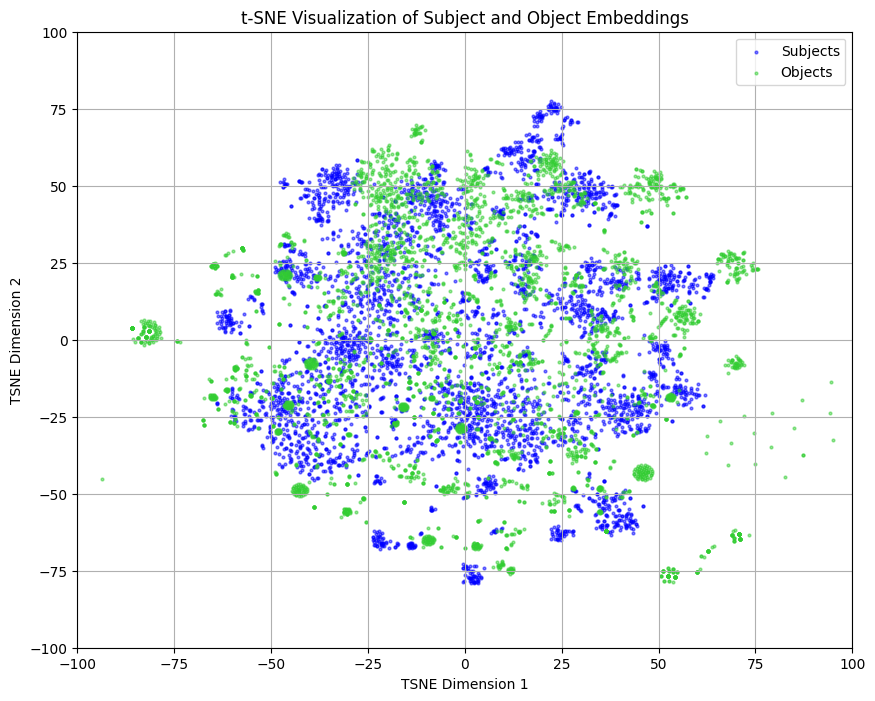

In [24]:
point_size = 4

plt.figure(figsize=(10, 8))

# Plot subject embeddings
plt.scatter(subject_reduced[:, 0], subject_reduced[:, 1], c='blue', label='Subjects', alpha=0.5, s=point_size)

# Plot object embeddings
plt.scatter(object_reduced[:, 0], object_reduced[:, 1], c='limegreen', label='Objects', alpha=0.5, s=point_size)

# Adding labels and title
plt.xlabel('TSNE Dimension 1')
plt.ylabel('TSNE Dimension 2')
plt.title('t-SNE Visualization of Subject and Object Embeddings')
plt.legend()

# Set x and y axis limits
plt.xlim(-100, 100)
plt.ylim(-100, 100)

# Show grid for better visual separation
plt.grid(True)

# Display the plot
plt.show()

### Visualizing the transformed embeddings

In [16]:
EMBEDDING_DIM = 768

checkpoint = torch.load('./../trained_models/entities_only/full_dim/42k_linear_bert_cls.pth')
# load the weights into my linear model
loaded_transformation = checkpoint['model_class'](EMBEDDING_DIM, EMBEDDING_DIM)
# loading the state dictionary
loaded_transformation.load_state_dict(checkpoint['state_dict'])
loaded_transformation.eval()

LinearTransformation(
  (linear): Linear(in_features=768, out_features=768, bias=False)
)

In [17]:
transformed_subject_embeddings = loaded_transformation(subject_embeddings)
transformed_object_embeddings = loaded_transformation(object_embeddings)

In [19]:
# Apply t-SNE to the transformed embeddings
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000)
transformed_subject_reduced = tsne.fit_transform(transformed_subject_embeddings.detach().numpy())
transformed_object_reduced = tsne.fit_transform(transformed_object_embeddings.detach().numpy())

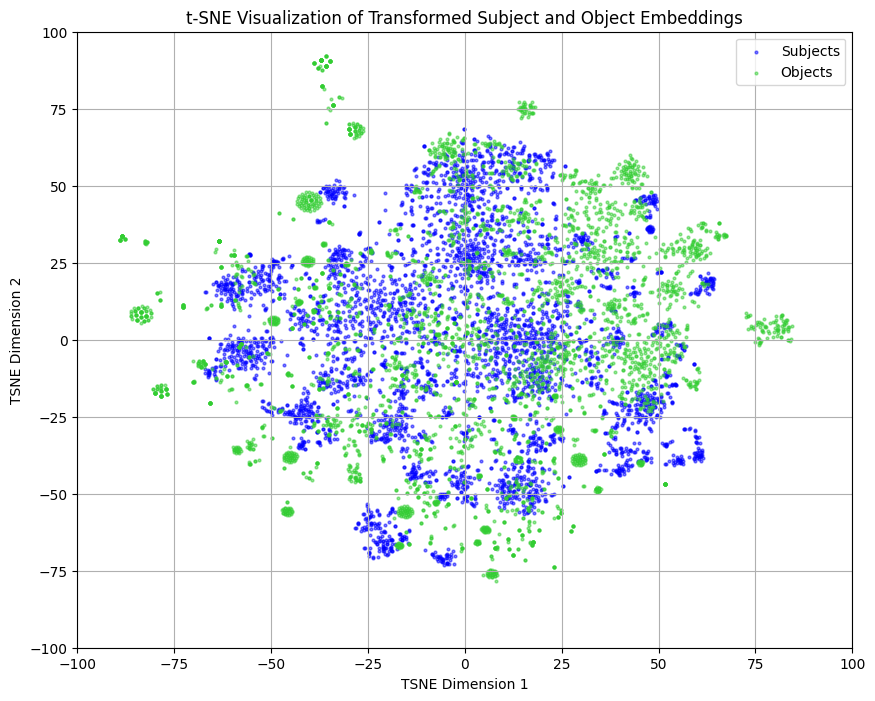

In [25]:
point_size = 4

plt.figure(figsize=(10, 8))

# Plot subject embeddings
plt.scatter(transformed_subject_reduced[:, 0], transformed_subject_reduced[:, 1], c='blue', label='Subjects', alpha=0.5, s=point_size)

# Plot object embeddings
plt.scatter(transformed_object_reduced[:, 0], transformed_object_reduced[:, 1], c='limegreen', label='Objects', alpha=0.5, s=point_size)

# Adding labels and title
plt.xlabel('TSNE Dimension 1')
plt.ylabel('TSNE Dimension 2')
plt.title('t-SNE Visualization of Transformed Subject and Object Embeddings')
plt.legend()

# Set x and y axis limits
plt.xlim(-100, 100)
plt.ylim(-100, 100)

# Show grid for better visual separation
plt.grid(True)

# Display the plot
plt.show()

### Visualizing the embeddings on the cartesian plane

In [12]:
knowledge_graph_embeddings = torch.randn(2, 100)
contextual_embeddings = torch.randn(2, 100)

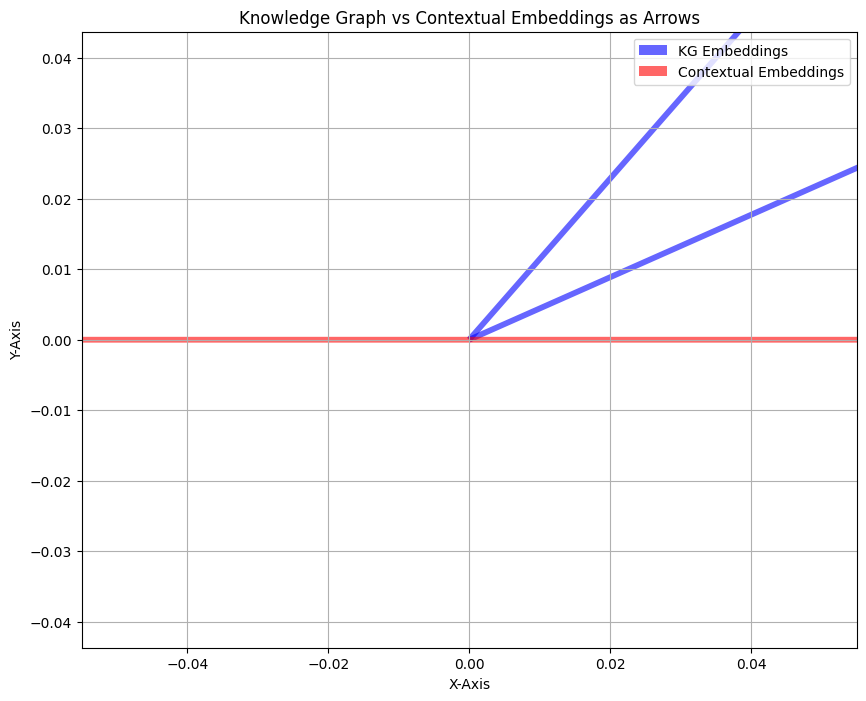

In [13]:
# Reduce contextual embeddings to 2D using PCA

pca = PCA(n_components=2)
contextual_embeddings_reduced = pca.fit_transform(contextual_embeddings.numpy())
knowledge_graph_embeddings_reduced = pca.transform(knowledge_graph_embeddings.numpy())

# Plot both knowledge graph and contextual embeddings as arrows
plt.figure(figsize=(10, 8))

# Plot knowledge graph embeddings
for i in range(knowledge_graph_embeddings_reduced.shape[0]):
    plt.quiver(0, 0, knowledge_graph_embeddings_reduced[i, 0], knowledge_graph_embeddings_reduced[i, 1], 
               angles='xy', scale_units='xy', scale=1, color='b', alpha=0.6, label='KG Embeddings' if i == 0 else "")

# Plot contextual embeddings
for i in range(contextual_embeddings_reduced.shape[0]):
    plt.quiver(0, 0, contextual_embeddings_reduced[i, 0], contextual_embeddings_reduced[i, 1], 
               angles='xy', scale_units='xy', scale=1, color='r', alpha=0.6, label='Contextual Embeddings' if i == 0 else "")

plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('Knowledge Graph vs Contextual Embeddings as Arrows')
plt.axis('equal')  # Ensure consistent scaling
plt.grid(True)
plt.legend()
plt.show()

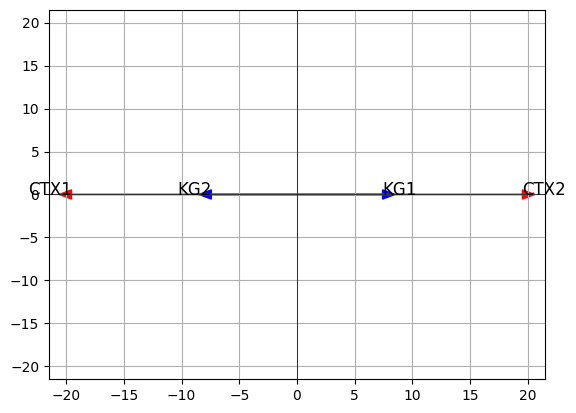

In [2]:
kg_embedding1 = requests.get('https://wembedder.toolforge.org/api/vector/Q577975')
kg_embedding2 = requests.get('https://wembedder.toolforge.org/api/vector/Q145')
response1 = kg_embedding1.json()
response2 = kg_embedding2.json()
# Convert lists to tensors
tensor1 = torch.tensor(response1['vector'])
tensor2 = torch.tensor(response2['vector'])

# Stack tensors to create a new tensor of shape (2, 100)
knowledge_graph_embeddings = torch.stack([tensor1, tensor2])

# Generate random contextual embeddings
contextual_embeddings = torch.randn(2, 768)

# Convert torch tensors to numpy arrays
kg_embeddings = knowledge_graph_embeddings.numpy()
ctx_embeddings = contextual_embeddings.numpy()

# Function to perform PCA and reduce dimensions to 2
def reduce_dimensions(embeddings):
    pca = PCA(n_components=2)
    return pca.fit_transform(embeddings)

# Reduce dimensions of both embeddings
kg_reduced = reduce_dimensions(kg_embeddings)
ctx_reduced = reduce_dimensions(ctx_embeddings)

# Plotting function
def plot_vectors(vectors, labels, colors):
    fig, ax = plt.subplots()
    
    # Calculate the limits for the plot
    max_val = np.max(np.abs(vectors)) * 1.1  # 10% padding
    
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    
    for vector, label, color in zip(vectors, labels, colors):
        ax.arrow(0, 0, vector[0], vector[1], head_width=max_val*0.05, head_length=max_val*0.05, fc=color, ec=color)
        ax.text(vector[0], vector[1], f'{label}', fontsize=12, ha='right' if vector[0] < 0 else 'left')

    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(True)
    plt.show()

# Prepare data for plotting
vectors = np.vstack([kg_reduced, ctx_reduced])
labels = ['KG1', 'KG2', 'CTX1', 'CTX2']
colors = ['blue', 'blue', 'red', 'red']

# Plot vectors
plot_vectors(vectors, labels, colors)

In [7]:
knowledge_graph_embeddings

tensor([[-0.2660, -1.4210,  0.4155,  1.0119, -0.1383,  1.3666,  1.0126,  0.1725,
          0.7589, -0.3760,  0.4136,  0.0929, -0.7834,  0.6968, -0.2126,  0.6415,
         -1.7014, -1.0468,  0.1058,  0.6078,  0.3353,  0.1421,  0.1079,  0.9288,
         -1.0561,  0.6648,  0.0804,  1.0402,  0.7229, -0.2011,  0.0066,  0.0388,
          0.1474, -1.2243, -1.3093,  1.0181,  0.9939, -0.1854, -0.5301,  1.6844,
         -0.2017,  0.8044,  0.3493, -0.9180, -2.8369,  1.7079, -0.7935, -0.5256,
         -1.9781,  1.3261,  0.2369, -0.1992, -0.3333,  0.4272, -0.6799,  0.9558,
          1.1932,  1.1475, -0.6337,  1.2874, -1.6333, -1.1188, -0.0572, -0.2527,
          0.6934, -0.3942,  0.0660,  0.4999,  0.9274,  2.6113,  0.2264, -0.9811,
          0.3627, -0.5571, -0.2443, -1.4800, -0.4593, -0.4774,  0.0577,  0.6936,
         -1.2322, -0.1160, -0.1237,  0.7020,  0.4680, -1.4004, -0.7648,  1.4668,
          0.2921,  0.7995, -0.1309,  1.2272,  0.3493,  1.2637, -0.6045, -0.2756,
         -0.0870, -1.0957,  

[100, 99.0, 98.01, 97.0299, 96.059601, 95.09900499, 94.1480149401, 93.206534790699, 92.27446944279201, 91.35172474836409, 90.43820750088045, 89.53382542587164, 88.63848717161292, 87.75210229989679, 86.87458127689783, 86.00583546412885, 85.14577710948757, 84.2943193383927, 83.45137614500877, 82.61686238355868, 81.7906937597231, 80.97278682212587, 80.16305895390461, 79.36142836436557, 78.56781408072192, 77.7821359399147, 77.00431458051555, 76.2342714347104, 75.4719287203633, 74.71720943315967, 73.97003733882806, 73.23033696543979, 72.49803359578539, 71.77305325982753, 71.05532272722925, 70.34476949995695, 69.64132180495739, 68.94490858690781, 68.25545950103874, 67.57290490602836, 66.89717585696808, 66.2282040983984, 65.56592205741441, 64.91026283684026, 64.26116020847186, 63.618548606387144, 62.98236312032327, 62.35253948912004, 61.72901409422884, 61.11172395328655, 60.50060671375368]


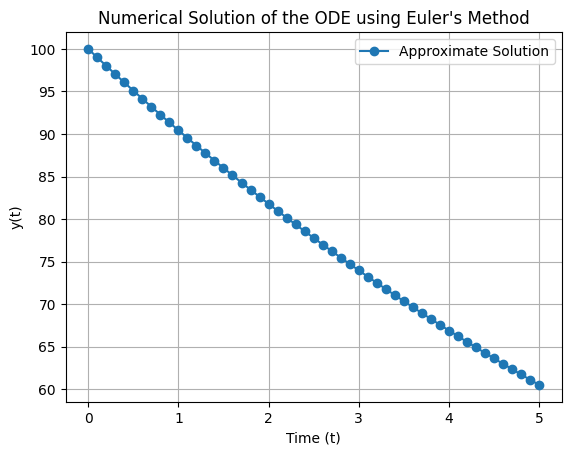

In [4]:
# Parameters
k = 0.1
y0 = 100
t_final = 5
h = 0.1

# Time points
t_points = np.arange(0, t_final + h, h)

# Euler's method to solve the ODE
def euler_method(y0, t_points, h):
    y_values = [y0]
    y = y0
    for t in t_points[:-1]:  # last point is excluded because we start at t=0 with y0
        y = y + h * (-k * y)  # Update step using Euler's formula
        y_values.append(y)
    return y_values

# Solving the ODE
y_values = euler_method(y0, t_points, h)
print(y_values)

# Plotting the results
plt.plot(t_points, y_values, label='Approximate Solution', marker='o')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Numerical Solution of the ODE using Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()